In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv("house_prices.csv")

In [6]:
# Basic info
print(df.head())

  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB
None


In [7]:
print(df.isnull().sum())

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


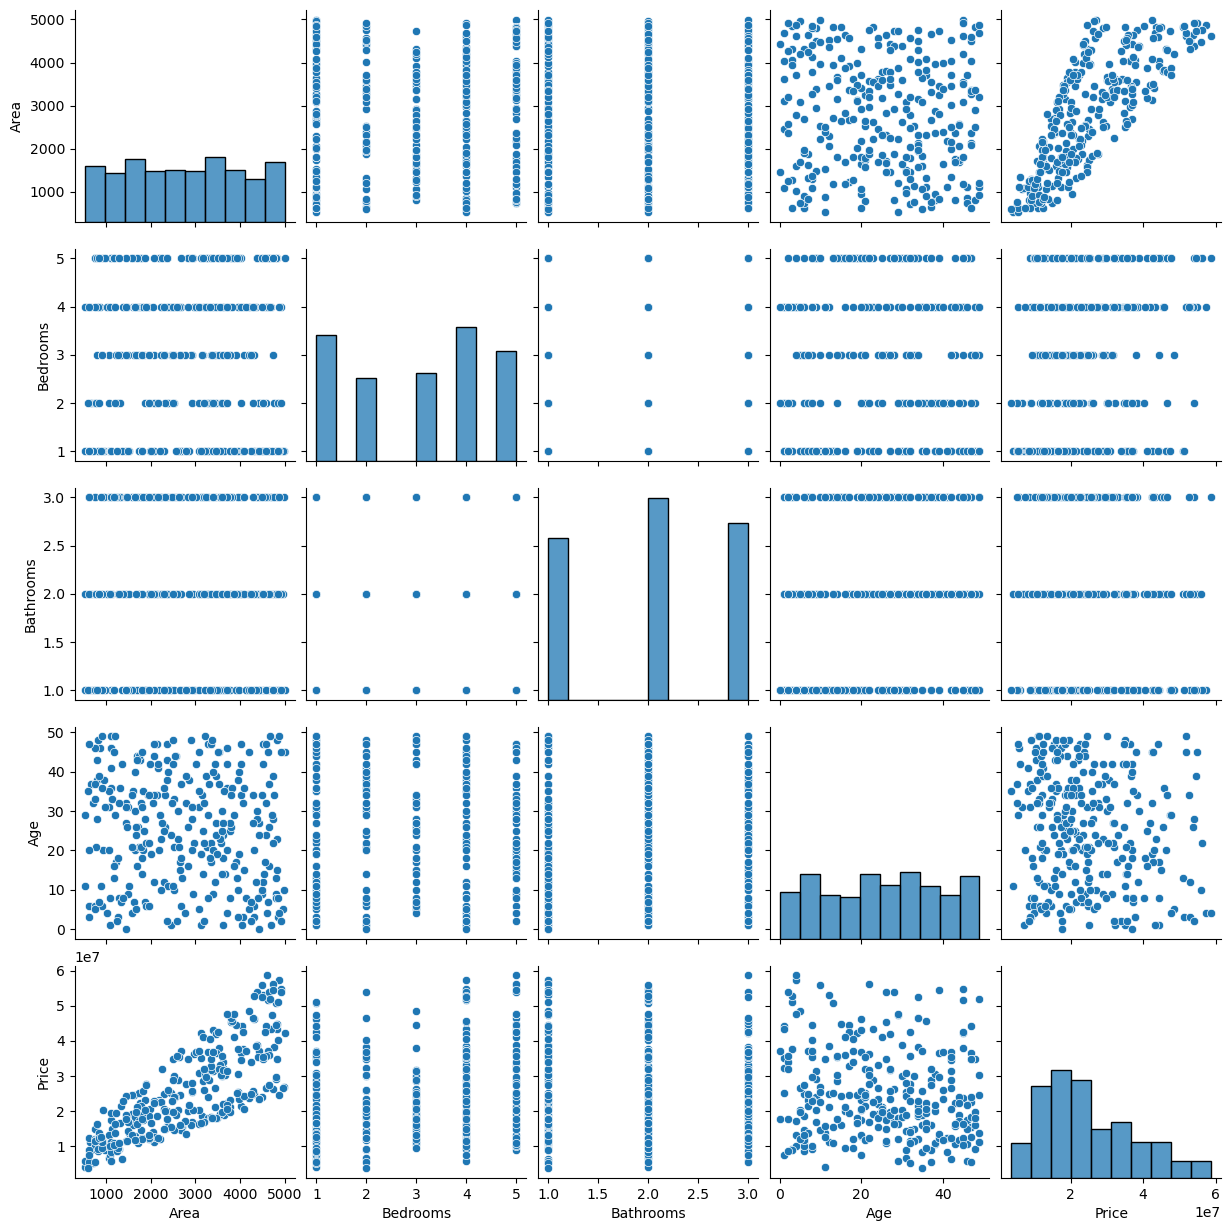

In [8]:
sns.pairplot(df)
plt.show()

In [ ]:
From the pairplot visualization:

- Area shows a strong positive correlation with price, indicating it is the most influential feature.
- Bedrooms and bathrooms show moderate relationships with price.
- Age does not show a significant correlation with price.
- The dataset contains discrete values for bedrooms and bathrooms, leading to vertical clustering in the plots.

Conclusion:
Area is the most important feature for predicting house prices, followed by bedrooms and bathrooms.

In [11]:
df = df.drop("Property_ID", axis=1)

In [12]:
df = pd.get_dummies(df, columns=["Location", "Property_Type"], drop_first=True)

In [13]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 2188736.3437038115
MSE: 8454330868276.604
R2 Score: 0.9406371185112241


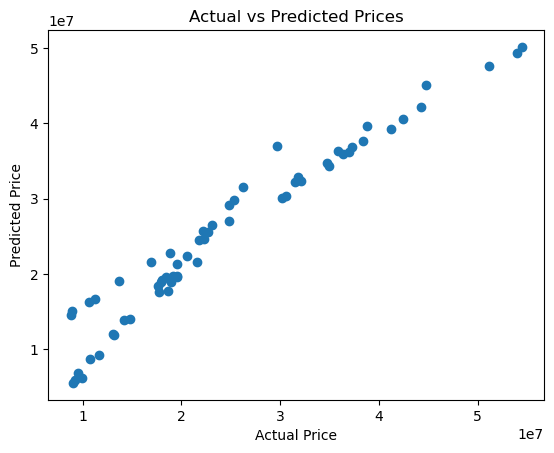

In [17]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.savefig("predictions_vs_actual.png")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))

RF R2: 0.9670554535338627


In [19]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Area                   0.694541
Location_Rural         0.203803
Location_Suburb        0.067828
Bedrooms               0.021067
Age                    0.008498
Bathrooms              0.002340
Property_Type_Villa    0.000969
Property_Type_House    0.000955
dtype: float64


In [20]:
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.9963375527023599
Test R2: 0.9670554535338627


In [21]:
from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, rf_pred))

MAE: 1546829.1666666667


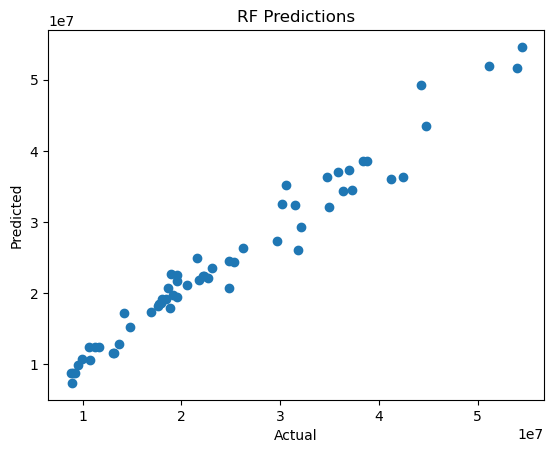

In [22]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RF Predictions")
plt.show()

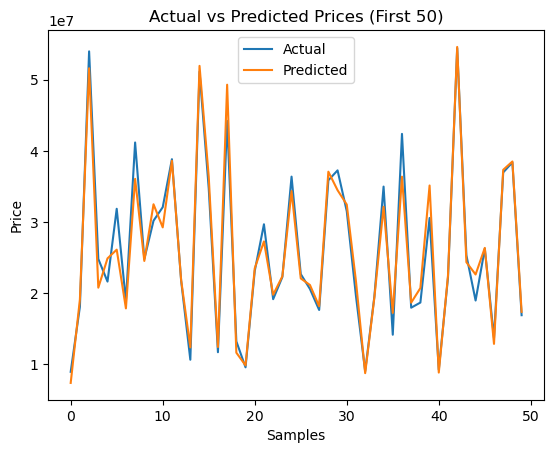

In [23]:
plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(rf_pred[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices (First 50)")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.show()

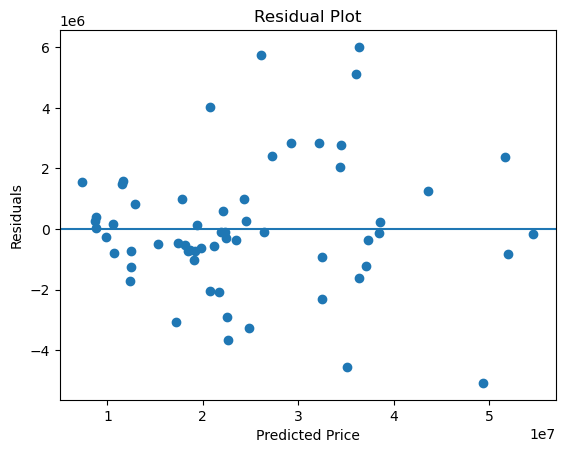

In [24]:
residuals = y_test - rf_pred

plt.figure()
plt.scatter(rf_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

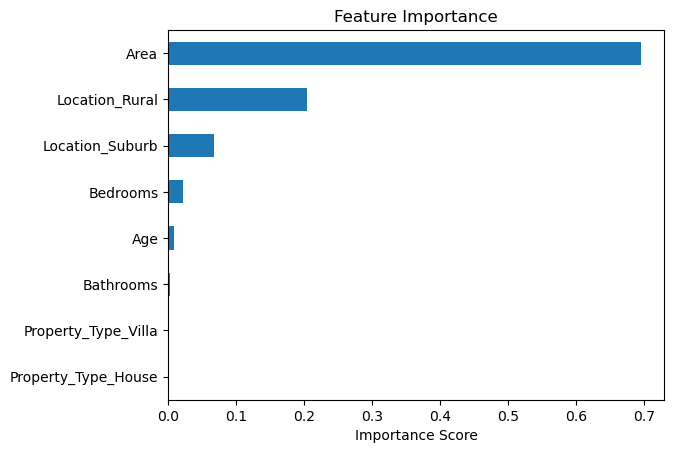

In [25]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

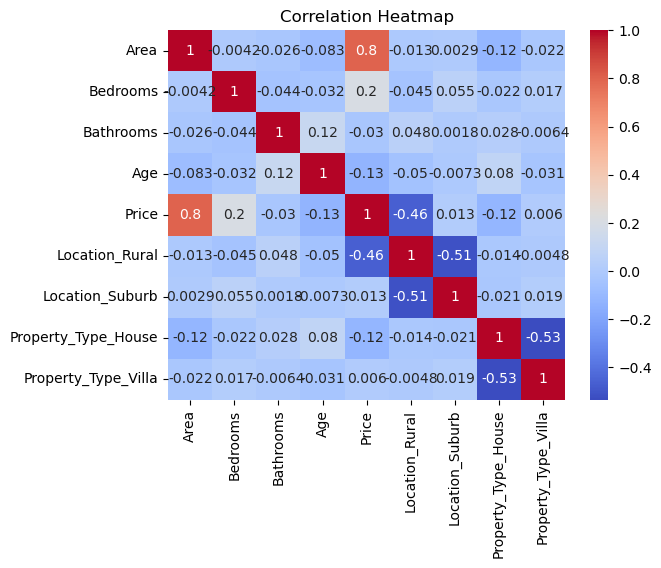

In [26]:
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

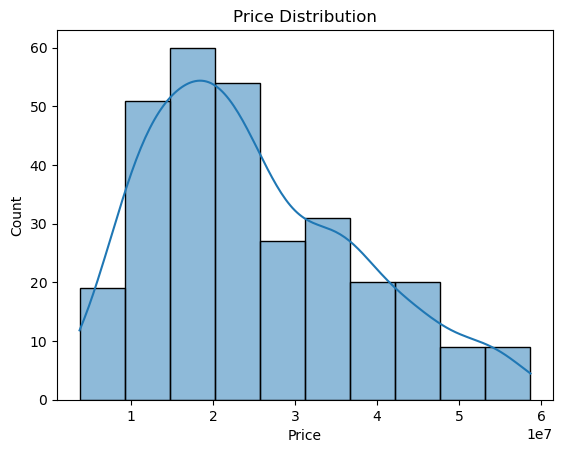

In [27]:
plt.figure()
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

In [8]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Train model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
importance.plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

ValueError: could not convert string to float: 'PROP0233'